In [1]:
import numpy as np
import mujoco
import os
from ament_index_python.packages import get_package_share_directory

from mjx_planner import cem_planner
from quat_math import quaternion_distance, quaternion_multiply, rotation_quaternion
# from sampling_based_planner.Simple_MLP.mlp_singledof import MLP, MLPProjectionFilter


/home/aks-lab/sampling_based_general/real_demo/sampling_based_planner/mjx_planner.py:223: SyntaxWarning: invalid escape sequence '\T'
  print("\Torque-controlled joints:")


In [2]:
# model_path = os.path.join(get_package_share_directory('real_demo'), 'panda_mjx', 'franka_emika_panda', 'panda_scene.xml')

print(os.getcwd())


/home/aks-lab/sampling_based_general/real_demo/sampling_based_planner


In [3]:
model_path = "../pendulum_mjx/scene.xml"
num_dof = 1
num_batch =32
num_steps = 20
maxiter_cem = 9
num_elite = 0.2
timestep = 0.02
maxiter_projection = 1
# max_joint_pos = 180.0*np.pi/180.0
max_joint_inttorque = 0.0 # Not used
max_joint_torque=1.0
max_joint_dtorque = 3.0
max_joint_ddtorque=9.0



model = mujoco.MjModel.from_xml_path(model_path)
data = mujoco.MjData(model)
cem = cem_planner(
            model=model,
            num_dof=num_dof, 
            num_batch=num_batch, 
            num_steps=num_steps, 
            maxiter_cem=maxiter_cem,
            num_elite=num_elite,
            timestep=timestep,
            maxiter_projection=maxiter_projection,
            max_joint_inttorque=max_joint_inttorque,
            max_joint_torque=max_joint_torque,
            max_joint_dtorque=max_joint_dtorque,
            max_joint_ddtorque=max_joint_ddtorque,
        )


\Torque-controlled joints:
  0: 'pendulum_joint' -> controlled: True

 Default backend: gpu
 Timestep: 0.02 
 CEM Iter: 9 
 Projection Iter: 1 
 Number of batches: 32 
 Number of steps per trajectory: 20 
 Time per trajectory: 0.4 
 Number of variables: 20 
 Number of Total constraints: 114


In [4]:
# import jax
# def compute_xi_samples(self, key, xi_mean, xi_cov ):
#     key, subkey = jax.random.split(key)
#     xi_samples = jax.random.multivariate_normal(key, xi_mean, xi_cov+0.003*jnp.identity(self.nvar), (self.num_batch, ))
#     return xi_samples, key

import jax
import jax.numpy as jnp

In [5]:
xi_mean_single = jnp.zeros(cem.nvar_single)
xi_cov_single = 1.0*jnp.identity(cem.nvar_single)
xi_mean = jnp.tile(xi_mean_single, cem.num_dof)
xi_cov = jnp.kron(jnp.eye(cem.num_dof), xi_cov_single)
key = jax.random.PRNGKey(42)
xi_samples, _ = cem.sampling.compute_xi_samples(key, xi_mean, xi_cov)

# init_pos = jnp.array([0.0, -0.3, 0.0, -2.0, 0.0, 1.7,
#                       0.0, -0.3, 0.0, -2.0, 0.0, 1.7])

# init_pos = jnp.array([1.5, -1.8, 1.75, -1.25, -1.6, 0, -1.5, -1.8, 1.75, -1.25, -1.6, 0])
init_pos = jnp.array([0.0])

init_vel = jnp.array([0.0])

init_acc = jnp.zeros_like(init_pos)
init_torque = jnp.zeros_like(init_pos)


In [6]:


lamda_init = jnp.zeros((num_batch, cem.nvar))
s_init = jnp.zeros((num_batch, cem.num_total_constraints))

cost_weights = {
    'theta': 100.0,
    'thetadot': 0.01,
    'control': 0.0
}

# model_path = "../walker_mjx/scene.xml"
# model = mujoco.MjModel.from_xml_path(model_path)


mjx_model = mujoco.mjx.put_model(model)
sim_data = data #mujoco.MjData(model)

current_mjx_data = mujoco.mjx.put_data(model, sim_data)


In [7]:
# opt_class = cem_planner(num_dof=num_dof, num_batch=num_batch, num_steps=num_steps, maxiter_cem=maxiter_cem,
#                         w_pos=w_pos, w_rot=w_rot, w_col=w_col, num_elite=num_elite, timestep=timestep,
#                         maxiter_projection=maxiter_projection,
#                         max_joint_pos = max_joint_pos, max_joint_vel=max_joint_vel, max_joint_acc=max_joint_acc, 
#                         max_joint_jerk=max_joint_jerk)

opt_class = cem_planner(model=model, num_dof=num_dof, num_batch=num_batch, num_steps=num_steps, timestep=timestep, maxiter_cem=maxiter_cem, num_elite=num_elite, 
maxiter_projection=maxiter_projection, max_joint_inttorque =  max_joint_inttorque, max_joint_torque = max_joint_torque, 
max_joint_dtorque = max_joint_dtorque, max_joint_ddtorque = max_joint_ddtorque)


\Torque-controlled joints:
  0: 'pendulum_joint' -> controlled: True

 Default backend: gpu
 Timestep: 0.02 
 CEM Iter: 9 
 Projection Iter: 1 
 Number of batches: 32 
 Number of steps per trajectory: 20 
 Time per trajectory: 0.4 
 Number of variables: 20 
 Number of Total constraints: 114


In [8]:
print("self.joint_mask_ctrl", opt_class.joint_mask_ctrl)
print("self.joint_mask_pos", opt_class.joint_mask_pos)

joint_ctrl_indices = jnp.where(opt_class.joint_mask_ctrl)[0]

print(joint_ctrl_indices)

self.joint_mask_ctrl [ True]
self.joint_mask_pos [ True]
[0]


In [9]:
print("self.joint_mask_ctrl", opt_class.joint_mask_ctrl)
print("self.joint_mask_pos", opt_class.joint_mask_pos)


self.joint_mask_ctrl [ True]
self.joint_mask_pos [ True]


In [10]:
actuator_joint_ids = model.actuator_trnid[:, 0]
actuator_ctrl_indices = [
    i for i, j in enumerate(actuator_joint_ids)
    if opt_class.joint_mask_ctrl[j]
]
print("actuator_joint_ids", actuator_joint_ids)
print("actuator_ctrl_indices", actuator_ctrl_indices)

actuator_joint_ids [0]
actuator_ctrl_indices [0]


In [11]:
# theta_seq, thetadot_seq, tip_pos_seq = opt_class.compute_dynamics_rollout_single(current_mjx_data, xi_samples[0,:], init_pos, init_vel)

In [12]:
# print("theta_seq", theta_seq.shape)
# print("thetadot_seq", thetadot_seq.shape)
# print("tip_pos_seq", tip_pos_seq.shape)

In [13]:
# import matplotlib.pyplot as plt
# plt.plot(theta_seq)
# plt.show

In [14]:
print("xi_samples", xi_samples.shape)
print("P", opt_class.P.shape)
# print(opt_class.Pdot.shape)
print("A_torque", opt_class.A_torque.shape)

xi_samples (32, 20)
P (20, 20)
A_torque (20, 20)


In [15]:

best_cost_cem, best_cost_list_cem, best_torques, best_traj, \
xi_mean, xi_cov, xi_samples_all, xi_filtered, torque_all, th_all, avg_primal_res, avg_fixed_res, \
primal_res, fixed_res, idx_min, tip_pos_planned, tip_pos = opt_class.compute_cem(
    current_mjx_data,
    xi_mean,
    xi_cov,
    init_pos,
    init_vel,
    init_acc,
    init_torque,
    lamda_init,
    s_init,
    xi_samples,
    cost_weights,
)

In [16]:
print(torque_all.shape)
print(best_torques.shape)

(9, 32, 20)
(20, 1)


In [17]:
print(primal_res.shape)
print(fixed_res.shape)
print(best_cost_cem.shape)

# print(avg_primal_res.shape)

(9, 1, 32)
(9, 1, 32)
(9,)


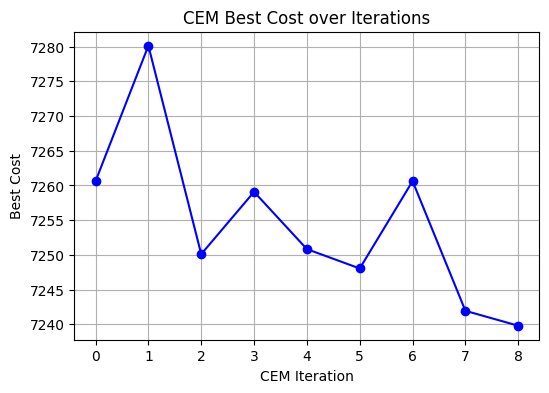

In [18]:
import matplotlib.pyplot as plt

# Assuming best_cost_cem is a 1D array of length = number of CEM iterations
plt.figure(figsize=(6,4))
plt.plot(best_cost_cem, marker='o', linestyle='-', color='blue')
plt.xlabel('CEM Iteration')
plt.ylabel('Best Cost')
plt.title('CEM Best Cost over Iterations')
plt.grid(True)
plt.show()


In [19]:
# primal_residuals = jnp.linalg.norm(primal_res, axis = -1)
# fixed_point_residuals = jnp.linalg.norm(fixed_res, axis = -1)

primal_residuals = primal_res[-1,:]
fixed_point_residuals = fixed_res[-1,:]
print(primal_residuals.shape)
print(fixed_point_residuals.shape)
print(torque_all.shape)
print(idx_min)

(1, 32)
(1, 32)
(9, 32, 20)
19


xi_samples (32, 20)


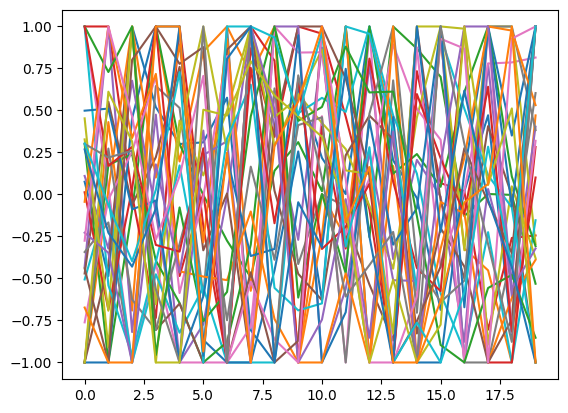

In [20]:
print("xi_samples", xi_samples.shape)
import matplotlib.pyplot as plt
plt.figure()
plt.plot(xi_samples.T)
plt.show()

In [21]:
# import matplotlib.pyplot as plt
# plt.figure()
# plt.plot(xi_filtered.T)
# plt.show()

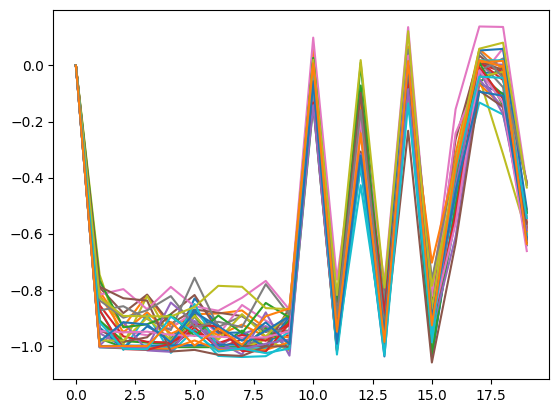

In [22]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(torque_all[-1].T)
plt.show()

In [23]:
print("th_all", th_all.shape)

th_all (9, 32, 20)


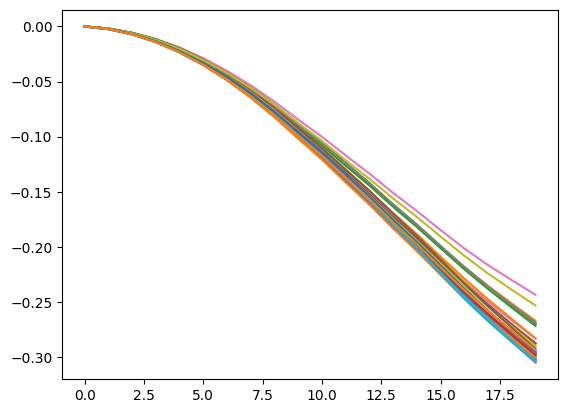

In [24]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(th_all[-1].T)
plt.show()

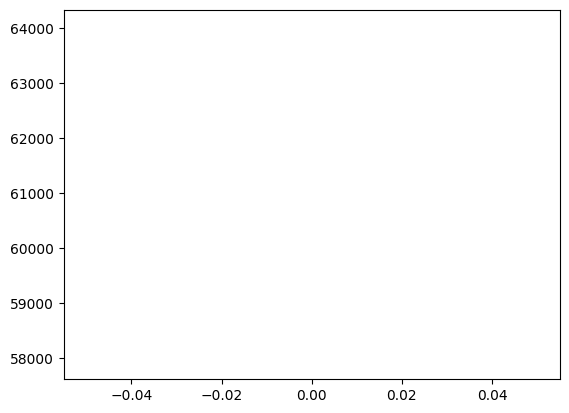

(1, 32)


In [25]:
import matplotlib.pyplot as plt
plt.figure()
# plt.plot(primal_residuals[:,idx_min])
# plt.plot(primal_residuals)
plt.plot(np.linalg.norm(primal_residuals, axis=-1))
plt.show()

print(primal_residuals.shape)

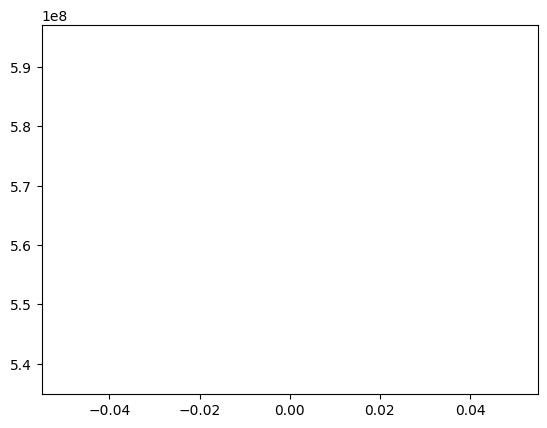

(1, 32)


In [26]:
import matplotlib.pyplot as plt
plt.figure()
# plt.plot(fixed_point_residuals)
plt.plot(np.linalg.norm(fixed_point_residuals, axis=-1))
plt.show()
print(fixed_point_residuals.shape)

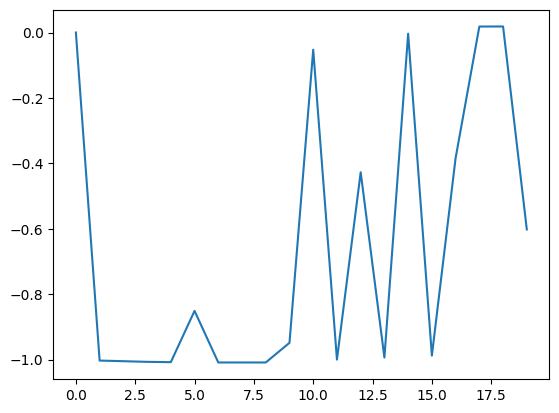

In [27]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(best_torques)
plt.show()

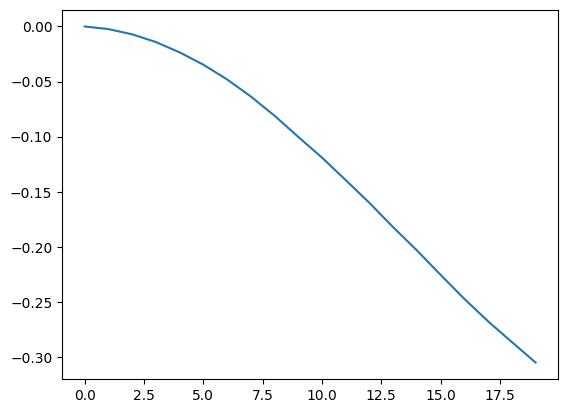

In [28]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(best_traj)
plt.show()

In [29]:
import os
import time
import numpy as np
import mujoco
from mujoco import viewer
DOF = num_dof

joint_names_pos = list()
joint_names_vel = list()
joint_names_ctrl = list()
for i in range(model.njnt):
        joint_type = model.jnt_type[i]
        n_pos = 7 if joint_type == mujoco.mjtJoint.mjJNT_FREE else 4 if joint_type == mujoco.mjtJoint.mjJNT_BALL else 1
        n_vel = 6 if joint_type == mujoco.mjtJoint.mjJNT_FREE else 3 if joint_type == mujoco.mjtJoint.mjJNT_BALL else 1
        n_ctrl = 6 if joint_type == mujoco.mjtJoint.mjJNT_FREE else 3 if joint_type == mujoco.mjtJoint.mjJNT_BALL else 1
        
        for _ in range(n_pos):
            joint_names_pos.append(mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_JOINT, i))
        for _ in range(n_vel):
            joint_names_vel.append(mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_JOINT, i))
        for _ in range(n_ctrl):
            joint_names_ctrl.append(mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_JOINT, i))

# robot_joints = np.array(['shoulder_pan_joint_1', 'shoulder_lift_joint_1', 'elbow_joint_1', 'wrist_1_joint_1', 'wrist_2_joint_1', 'wrist_3_joint_1',
#                                 'shoulder_pan_joint_2', 'shoulder_lift_joint_2', 'elbow_joint_2', 'wrist_1_joint_2', 'wrist_2_joint_2', 'wrist_3_joint_2'])
robot_joints = np.array(['pendulum_joint'])
joint_mask_pos = np.isin(joint_names_pos, robot_joints)
joint_mask_vel = np.isin(joint_names_vel, robot_joints)
joint_mask_ctrl = np.isin(joint_names_ctrl, robot_joints)


In [30]:
# print(eef_0.shape)
# print(eef_1.shape)
# print(eef_0_planned.shape)
# print(eef_0_.shape)
# print(eef_1_.shape)


In [31]:

# class Visualizer:
#     def __init__(self, thetadot: np.ndarray):
#         """
#         thetadot: shape (T, DOF) or (T, N) joint velocities over time
#         """
#         # self.init_joint_state = cem.init_joint_position

#         self.init_joint_state = jnp.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

        
#         # Load model
#         # model_path = f"{os.path.dirname(__file__)}/ur5e_hande_mjx/scene.xml"
#         model_path = "../walker_mjx/scene.xml"
#         self.model = mujoco.MjModel.from_xml_path(model_path)
#         self.model.opt.timestep = 0.1
#         self.data = mujoco.MjData(self.model)

#         # Set initial joint state
#         # self.data.qpos[:DOF] = self.init_joint_state

#         self.data.qpos[joint_mask_pos] = self.init_joint_state

#         # Store trajectory
#         self.thetadot = thetadot


#     def render_trace(self, viewer_, torso_trace=None, torso_trace_planned=None):
#         """Render the end-effector trajectory trace in the viewer for all batches.
#         Any None inputs will be skipped."""
#         # Clear any existing overlay geoms
#         viewer_.user_scn.ngeom = 0
        
#         # Define colors for each type (RGBA format)
#         colors = {
#             'torso_trace': [1, 0, 0, 0.5],      # Red
#             'torso_trace_planned': [0, 0, 1, 0.5],  # Blue
#         }
        
#         # Collect traces (skip if None)
#         traces = [
#             ('torso_trace', torso_trace),
#             ('torso_trace_planned', torso_trace_planned)
#         ]
        
#         for trace_name, trace_data in traces:
#             if trace_data is None:
#                 continue  # skip plotting this trace

#             rgba = colors[trace_name]

#             if trace_name in ['torso_trace_planned']:
#                 # Shape: (num_steps, 7)
#                 positions = trace_data[:, :3]
#                 for pos in positions:
#                     self._add_sphere(viewer_, pos, rgba)
#             else:
#                 # Shape: (1, num_batch, num_steps, 7)
#                 num_batches = trace_data.shape[1]
#                 for batch_idx in range(num_batches):
#                     positions = trace_data[-1, batch_idx, :, :3]
#                     for pos in positions:
#                         self._add_sphere(viewer_, pos, rgba)

#     def _add_sphere(self, viewer_, pos, rgba):
#         """Helper method to add a sphere to the viewer scene."""
#         geom_id = viewer_.user_scn.ngeom
#         if geom_id >= viewer_.user_scn.maxgeom:
#             return  # Skip if we've reached the maximum number of geoms

#         viewer_.user_scn.ngeom += 1

#         mujoco.mjv_initGeom(
#             viewer_.user_scn.geoms[geom_id],
#             type=mujoco.mjtGeom.mjGEOM_SPHERE,
#             size=[0.02, 0.02, 0.02],  # radius 1 cm
#             pos=pos,
#             mat=np.eye(3).flatten(),
#             rgba=rgba
#         )
   
    
    
    
#     def view_traj(self):
#         with viewer.launch_passive(self.model, self.data) as viewer_:
#             viewer_.cam.distance = 4
#             i = 0

#             while viewer_.is_running():
#                 step_start = time.time()

#                 # Apply velocity
#                 # self.data.qvel[:DOF] = self.thetadot[i]
#                 self.data.qvel[joint_mask_vel] = self.thetadot[i]


#                 self.data.qpos[joint_mask_pos] = self.init_joint_state

#                 mujoco.mj_step(self.model, self.data)
#                 # mujoco.mj_forward(self.model, self.data)
#                 viewer_.sync()

#                 # Keep real time
#                 dt = self.model.opt.timestep - (time.time() - step_start)
#                 if dt > 0:
#                     time.sleep(dt)

#                 # Loop trajectory
#                 if i < self.thetadot.shape[0] - 1:
#                     i += 1
#                 else:
#                     self.data.qvel[:DOF] = np.zeros(DOF)
#                     self.data.qpos[:DOF] = self.init_joint_state
#                     i = 0


#                 self.render_trace(viewer_, torso_trace= torso_pos,  
#                                   torso_trace_planned = torso_pos_planned)


# def main():
#     # Example: sinusoidal velocities for 6 joints
#     # timesteps = 1000
#     # t = np.linspace(0, 10, timesteps)
#     # thetadot = np.stack([0.0 * np.sin(t) for _ in range(DOF)], axis=1)

#     thetadot = best_vels
#     # thetadot = np.mean(torque_all[1:int(num_steps*0.5)], axis=0)

#     print("best_vels", best_vels)

#     print(thetadot.shape)

#     viz = Visualizer(thetadot)
#     viz.view_traj()


# if __name__ == "__main__":
#     main()


In [32]:
# import time
# import numpy as np
# import jax.numpy as jnp
# import mujoco
# from mujoco import viewer


# class Visualizer:
#     def __init__(self, thetadot: np.ndarray):
#         """
#         thetadot: shape (T, DOF) or (T, N) joint velocities over time
#         """
#         # Initial joint state
#         self.init_joint_state = jnp.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

#         # Load MuJoCo model
#         model_path = "../walker_mjx/scene.xml"
#         self.model = mujoco.MjModel.from_xml_path(model_path)
#         self.model.opt.timestep = 0.1
#         self.data = mujoco.MjData(self.model)

#         # Set initial joint positions
#         self.data.qpos[joint_mask_pos] = self.init_joint_state

#         # Store trajectory
#         self.thetadot = thetadot


#     def render_trace(self, viewer_, torso_trace=None, torso_trace_planned=None):
#         """
#         Render the end-effector trajectory trace in the viewer.
#         The red trace fades in transparency (first point opaque, last transparent).
#         """
#         # Clear previous geoms
#         viewer_.user_scn.ngeom = 0
        
#         # Base colors (RGBA)
#         colors = {
#             'torso_trace': [1, 0, 0, 1.0],        # Red (fully opaque start)
#             'torso_trace_planned': [0, 0, 1, 0.7] # Blue (semi-transparent constant)
#         }
        
#         # Collect traces
#         traces = [
#             ('torso_trace', torso_trace),
#             ('torso_trace_planned', torso_trace_planned)
#         ]
        
#         for trace_name, trace_data in traces:
#             if trace_data is None:
#                 continue

#             base_rgba = np.array(colors[trace_name], dtype=float)

#             if trace_name == 'torso_trace_planned':
#                 # Shape: (num_steps, 7)
#                 positions = trace_data[:, :3]
#                 # Constant transparency for planned trace
#                 for pos in positions:
#                     self._add_sphere(viewer_, pos, base_rgba)

#             else:
#                 # Shape: (1, num_batch, num_steps, 7)
#                 num_batches = trace_data.shape[1]
#                 for batch_idx in range(num_batches):
#                     positions = trace_data[-1, batch_idx, :, :3]
#                     num_points = positions.shape[0]

#                     # Create a fading alpha (1.0 → 0.1)
#                     alphas = np.linspace(1.0, 0.1, num_points)

#                     for i, pos in enumerate(positions):
#                         rgba = base_rgba.copy()
#                         rgba[3] = alphas[i]
#                         self._add_sphere(viewer_, pos, rgba)


#     def _add_sphere(self, viewer_, pos, rgba):
#         """Helper method to add a sphere to the viewer scene."""
#         geom_id = viewer_.user_scn.ngeom
#         if geom_id >= viewer_.user_scn.maxgeom:
#             return  # Skip if we've reached the maximum number of geoms

#         viewer_.user_scn.ngeom += 1

#         mujoco.mjv_initGeom(
#             viewer_.user_scn.geoms[geom_id],
#             type=mujoco.mjtGeom.mjGEOM_SPHERE,
#             size=[0.02, 0.02, 0.02],  # sphere radius 2 cm
#             pos=pos,
#             mat=np.eye(3).flatten(),
#             rgba=rgba
#         )


#     def view_traj(self):
#         """Run MuJoCo passive viewer and animate velocity playback."""
#         with viewer.launch_passive(self.model, self.data) as viewer_:
#             viewer_.cam.distance = 4
#             i = 0

#             while viewer_.is_running():
#                 step_start = time.time()

#                 # Apply joint velocities
#                 self.data.qvel[joint_mask_vel] = self.thetadot[i]
#                 self.data.qpos[joint_mask_pos] = self.init_joint_state

#                 mujoco.mj_step(self.model, self.data)
#                 viewer_.sync()

#                 # Keep real-time playback
#                 dt = self.model.opt.timestep - (time.time() - step_start)
#                 if dt > 0:
#                     time.sleep(dt)

#                 # Loop trajectory
#                 if i < self.thetadot.shape[0] - 1:
#                     i += 1
#                 else:
#                     self.data.qvel[:] = 0.0
#                     self.data.qpos[joint_mask_pos] = self.init_joint_state
#                     i = 0

#                 # Draw traces
#                 self.render_trace(
#                     viewer_,
#                     torso_trace=torso_pos,
#                     torso_trace_planned=torso_pos_planned
#                 )


# def main():
#     # Example torque array (replace with best_torques)
#     thetadot = best_torques
#     print("best_torques", best_torques)
#     print(thetadot.shape)

#     viz = Visualizer(thetadot)
#     # viz.view_traj()


# if __name__ == "__main__":
#     main()


In [33]:
def set_axes_equal(ax):
    """Make axes of a 3D plot have equal scale."""
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = x_limits[1] - x_limits[0]
    y_range = y_limits[1] - y_limits[0]
    z_range = z_limits[1] - z_limits[0]
    max_range = max(x_range, y_range, z_range)

    x_middle = np.mean(x_limits)
    y_middle = np.mean(y_limits)
    z_middle = np.mean(z_limits)

    ax.set_xlim3d([x_middle - max_range/2, x_middle + max_range/2])
    ax.set_ylim3d([y_middle - max_range/2, y_middle + max_range/2])
    ax.set_zlim3d([z_middle - max_range/2, z_middle + max_range/2])

In [34]:
print("tip_pos", tip_pos.shape)

tip_pos (9, 32, 20, 3)


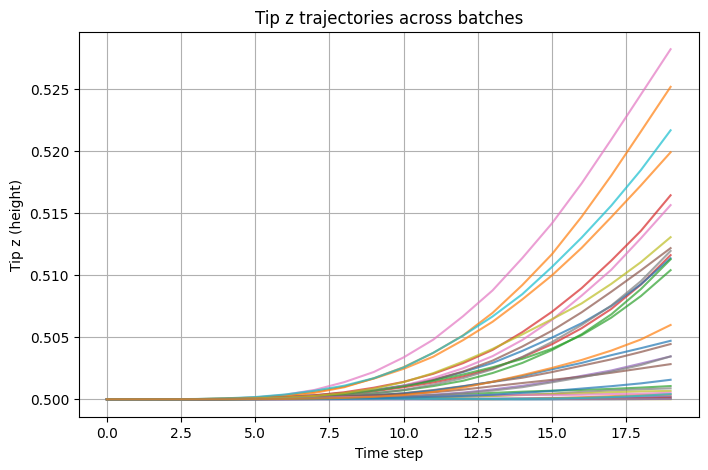

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# 1st Cem iter
arr_0_ = tip_pos[0]  # shape: (num_batch, num_steps, 3)

num_batch, num_steps, _ = arr_0_.shape

# Create a 2D plot for z trajectories
plt.figure(figsize=(8, 5))

for b in range(num_batch):
    z_0_ = arr_0_[b, :, 2]  # extract z-coordinate
    plt.plot(range(num_steps), z_0_, alpha=0.7, label=f"batch {b+1}" if num_batch <= 10 else None)

# Labels
plt.xlabel("Time step")
plt.ylabel("Tip z (height)")
plt.title("Tip z trajectories across batches")
if num_batch <= 10:
    plt.legend()
plt.grid(True)

plt.show()

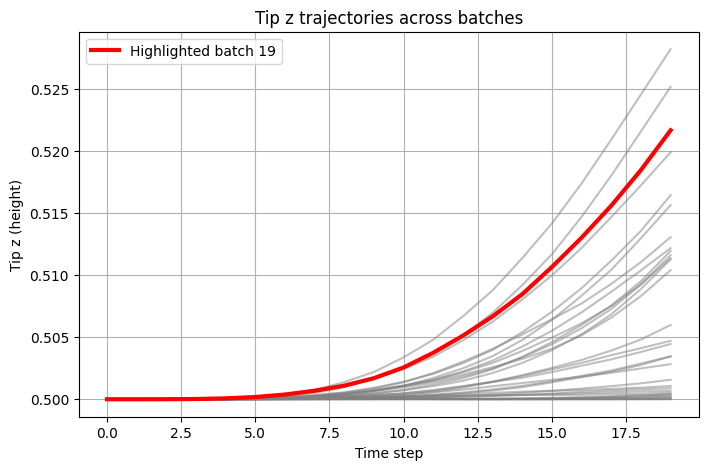

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# 1st Cem iter
arr_0_ = tip_pos[0]  # shape: (num_batch, num_steps, 3)
num_batch, num_steps, _ = arr_0_.shape

  # example: batch index to highlight

plt.figure(figsize=(8, 5))

# Plot all trajectories with light color
for b in range(num_batch):
    z_0_ = arr_0_[b, :, 2]
    if b != idx_min:
        plt.plot(range(num_steps), z_0_, color='gray', alpha=0.5)

# Highlight the chosen batch in red and thick
z_highlight = arr_0_[idx_min, :, 2]
plt.plot(range(num_steps), z_highlight, color='red', linewidth=3, label=f"Highlighted batch {idx_min}")

# Labels
plt.xlabel("Time step")
plt.ylabel("Tip z (height)")
plt.title("Tip z trajectories across batches")
plt.legend()
plt.grid(True)

plt.show()


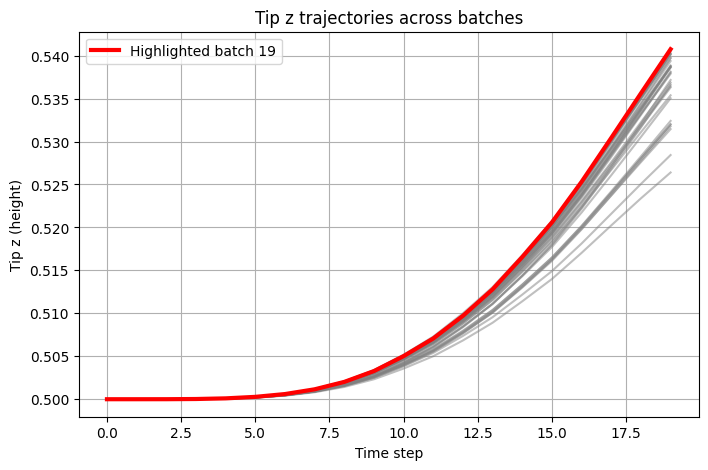

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# 1st Cem iter
arr_0_ = tip_pos[-1]  # shape: (num_batch, num_steps, 3)
num_batch, num_steps, _ = arr_0_.shape

  # example: batch index to highlight

plt.figure(figsize=(8, 5))

# Plot all trajectories with light color
for b in range(num_batch):
    z_0_ = arr_0_[b, :, 2]
    if b != idx_min:
        plt.plot(range(num_steps), z_0_, color='gray', alpha=0.5)

# Highlight the chosen batch in red and thick
z_highlight = arr_0_[idx_min, :, 2]
plt.plot(range(num_steps), z_highlight, color='red', linewidth=3, label=f"Highlighted batch {idx_min}")

# Labels
plt.xlabel("Time step")
plt.ylabel("Tip z (height)")
plt.title("Tip z trajectories across batches")
plt.legend()
plt.grid(True)

plt.show()
